# Módulo 5 · Tema 1 · Sesión 1 — *Notebook base*
## Definir y **validar** los KPIs antes de llevarlos al tablero

**Diplomado Machine Learning en Seguros · FC UNAM**

---

Este notebook es el **laboratorio**: aquí definimos la lógica que el tablero
(`app_streamlit.py`) solo va a **mostrar**. Pero el objetivo de hoy no es solo *calcular*
KPIs — es aprender a **validarlos**. Un número mal calculado se ve igual de convincente en
una tarjeta; la diferencia la hace el método.

**Método de validación que practicamos hoy:**
1. **Rangos y nulos** — ¿los datos tienen sentido? ¿Qué nulos son *esperados* y cuáles no?
2. **Ponderado vs. simple** — casi ningún KPI actuarial es un promedio simple; lo comprobamos.
3. **Cruce contra una referencia conocida** — el número debe coincidir con el del Módulo 4.
4. **Una identidad que debe cumplirse** — prima pura = frecuencia × severidad.


## 0 · Setup

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [4]:
def ruta_datos():
    """Primera ruta que exista (parquet o pkl). Evita el FileNotFoundError por ruta."""
    for r in ["datos/datos.parquet", "datos/datos.pkl",
              "../datos/datos.parquet",
              "../Modulo_4/m4t2_sesion1/datos/datos.parquet",
              "../Modulo_4/m4t2_sesion1/datos/datos.pkl"]:
        if os.path.exists(r):
            return r
    raise FileNotFoundError("No encuentro la cartera (datos.parquet / datos.pkl).")

RUTA = ruta_datos()
datos = pd.read_parquet(RUTA) if RUTA.endswith(".parquet") else pd.read_pickle(RUTA)
print("Cargado:", RUTA)
print(f"{len(datos):,} pólizas · {datos.shape[1]} columnas")

Cargado: ../Modulo_4/m4t2_sesion1/datos/datos.parquet
163,212 pólizas · 18 columnas


## 1 · Conocer la cartera

Es la misma cartera de auto sobre la que ajustamos los GLM en el Módulo 4.

In [5]:
datos.head()

,id_poliza,exposicion,num_siniestros,tiene_siniestro,monto_total,severidad,cobertura,sexo,edad_conductor,uso,flotilla,combustible,potencia,antiguedad_vehiculo,nivel_bonus,codigo_postal,longitud,latitud
0,1,1.0000,1,1,"1,618.0010","1,618.0010",RC,Hombre,50.0000,Particular,No,Gasolina,77.0000,12.0000,5.0000,1000,4.3552,50.8454
1,2,1.0000,0,0,0.0000,NaN,Limitada,Mujer,64.0000,Particular,No,Gasolina,66.0000,3.0000,5.0000,1000,4.3552,50.8454
2,3,1.0000,0,0,0.0000,NaN,RC,Hombre,60.0000,Particular,No,Diesel,70.0000,10.0000,0.0000,1000,4.3552,50.8454
3,4,1.0000,0,0,0.0000,NaN,RC,Hombre,77.0000,Particular,No,Gasolina,57.0000,15.0000,0.0000,1000,4.3552,50.8454
4,5,0.0466,1,1,155.9746,155.9746,RC,Mujer,28.0000,Particular,No,Gasolina,70.0000,7.0000,9.0000,1000,4.3552,50.8454


In [6]:
# Las columnas que usaremos hoy
cols = ['exposicion','num_siniestros','monto_total','severidad',
        'cobertura','sexo','uso','edad_conductor','nivel_bonus']
datos[cols].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
exposicion,"163,212.0000",NaN,NaN,NaN,0.8897,0.2442,0.0027,1.0000,1.0000,1.0000,1.0000
num_siniestros,"163,212.0000",NaN,NaN,NaN,0.1239,0.3675,0.0000,0.0000,0.0000,0.0000,5.0000
monto_total,"163,212.0000",NaN,NaN,NaN,162.1509,"1,374.5758",0.0000,0.0000,0.0000,0.0000,"140,032.4245"
severidad,"18,276.0000",NaN,NaN,NaN,"1,307.6115","3,487.2084",0.0248,142.6379,527.4183,"1,426.3793","80,499.6046"
cobertura,163212,3,RC,95124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexo,163212,2,Hombre,120044,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uso,163212,2,Particular,155334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad_conductor,"163,212.0000",NaN,NaN,NaN,47.0009,14.8316,18.0000,35.0000,46.0000,58.0000,95.0000
nivel_bonus,"163,212.0000",NaN,NaN,NaN,3.2682,3.9982,0.0000,0.0000,1.0000,6.0000,22.0000


## 2 · Validación de los datos — ¿podemos confiar?

Primer paso del método. Antes de calcular un KPI, revisamos nulos y rangos. **Ojo:** no
todo nulo es un problema.

In [7]:
# Nulos por columna
nulos = datos.isna().sum()
print(nulos[nulos > 0] if nulos.any() else "Sin nulos")

severidad    144936
dtype: int64


**Lectura del resultado (esto es lo que hay que enseñar):**

`severidad` tiene muchos nulos — y eso es **esperado**, no un error: la severidad
(costo medio por siniestro) solo existe cuando **hubo** siniestro. En las pólizas con
`num_siniestros = 0` no hay severidad que calcular → `NaN`.

Distinguir un **nulo esperado** de uno **sospechoso** es parte de validar. Si `exposicion`
o `cobertura` tuvieran nulos, eso *sí* sería para investigar.

In [8]:
# Confirmamos que TODOS los nulos de severidad caen en pólizas sin siniestro
sin_sin = datos['num_siniestros'] == 0
print("¿Todo NaN de severidad está en pólizas con 0 siniestros?",
      datos.loc[sin_sin, 'severidad'].isna().all(),
      "· ¿alguna póliza con siniestro tiene severidad NaN?",
      datos.loc[~sin_sin, 'severidad'].isna().any())

¿Todo NaN de severidad está en pólizas con 0 siniestros? True · ¿alguna póliza con siniestro tiene severidad NaN? False


In [9]:
# Rangos: valores imposibles saltarían aquí
for c in ['exposicion','num_siniestros','monto_total','severidad']:
    print(f"{c:15s} min={datos[c].min():>12,.4f}   max={datos[c].max():>14,.2f}")
assert (datos['exposicion'] > 0).all(), "Exposición <= 0: revisar"
assert (datos['num_siniestros'] >= 0).all(), "Siniestros negativos: revisar"
print("Rangos OK ✔")

exposicion      min=      0.0027   max=          1.00
num_siniestros  min=      0.0000   max=          5.00
monto_total     min=      0.0000   max=    140,032.42
severidad       min=      0.0248   max=     80,499.60
Rangos OK ✔


## 3 · KPIs: ponderado vs. simple  ← *el punto de hoy*

La trampa más común en KPIs actuariales: usar el **promedio simple**. Vamos a calcular la
frecuencia de las **dos** formas y comparar.

In [10]:
# ✗ Forma INGENUA: promedio simple de la tasa por póliza
freq_simple = (datos['num_siniestros'] / datos['exposicion']).mean()

# ✓ Forma CORRECTA: ponderada por exposición
freq_ponderada = datos['num_siniestros'].sum() / datos['exposicion'].sum()

print(f"Frecuencia (promedio simple)  : {freq_simple:.4f}   ✗")
print(f"Frecuencia (ponderada)        : {freq_ponderada:.4f}   ✓")
print(f"Diferencia                    : {abs(freq_simple/freq_ponderada-1):.1%}")

Frecuencia (promedio simple)  : 0.1573   ✗
Frecuencia (ponderada)        : 0.1392   ✓
Diferencia                    : 13.0%


**¿Por qué difieren?** El promedio simple pesa **igual** una póliza de 1 mes de
exposición que una de 1 año. La forma ponderada da a cada póliza el peso de su exposición,
que es lo correcto: la frecuencia es siniestros por año-póliza *del portafolio*, no el
promedio de tasas individuales.

**Conclusión de método:** cuando dos formas "razonables" dan números distintos, hay que
saber *cuál* es la correcta y *por qué*. Aquí, siempre la ponderada.

In [11]:
# Definimos las funciones BUENAS (son las que usará el tablero)
def kpi_frecuencia(df):
    """Σ siniestros / Σ exposición (ponderada por exposición)."""
    return df['num_siniestros'].sum() / df['exposicion'].sum()

def kpi_severidad_media(df):
    """Ponderada por nº de siniestros, solo sobre pólizas con N>0."""
    con = df[df['num_siniestros'] > 0]
    return np.average(con['severidad'], weights=con['num_siniestros']) if len(con) else np.nan

def kpi_prima_pura(df):
    """Σ monto / Σ exposición  (= frecuencia × severidad)."""
    return df['monto_total'].sum() / df['exposicion'].sum()

print(f"Frecuencia      : {kpi_frecuencia(datos):.4f}")
print(f"Severidad media : {kpi_severidad_media(datos):,.2f}")
print(f"Prima pura      : {kpi_prima_pura(datos):,.2f}")

Frecuencia      : 0.1392
Severidad media : 1,309.17
Prima pura      : 182.24


## 4 · Cruce contra el Módulo 4 (referencia conocida)

Tercer paso del método: el número debe **coincidir** con lo que ya obtuvimos en M4. Si no,
el número está mal, no la referencia.

In [12]:
REF_M4 = {'frecuencia': 0.1392, 'severidad': 1309, 'prima_pura': 182.24}
calc = {'frecuencia': kpi_frecuencia(datos),
        'severidad':  kpi_severidad_media(datos),
        'prima_pura': kpi_prima_pura(datos)}
for k in REF_M4:
    ok = abs(calc[k] - REF_M4[k]) / REF_M4[k] < 0.01
    print(f"{k:11s} ref≈{REF_M4[k]:<10} calc={calc[k]:<12.4f} {'✅' if ok else '⚠️ revisar'}")

frecuencia  ref≈0.1392     calc=0.1392       ✅
severidad   ref≈1309       calc=1309.1749    ✅
prima_pura  ref≈182.24     calc=182.2445     ✅


## 5 · Una identidad que debe cumplirse

Cuarto paso: **prima pura = frecuencia × severidad**. Es una identidad matemática (porque
`monto_total = severidad × num_siniestros`), así que si no cuadra, hay un error de
ponderación en alguno de los tres KPIs. Es la prueba de sanidad más barata que existe.

In [13]:
pp_directa  = kpi_prima_pura(datos)
pp_indirecta = kpi_frecuencia(datos) * kpi_severidad_media(datos)
print(f"Prima pura directa      : {pp_directa:,.4f}")
print(f"Frecuencia × Severidad  : {pp_indirecta:,.4f}")
print(f"Diferencia relativa     : {abs(pp_directa/pp_indirecta-1):.2e}   (debe ser ~0)")

Prima pura directa      : 182.2445
Frecuencia × Severidad  : 182.2445
Diferencia relativa     : 0.00e+00   (debe ser ~0)


## 6 · KPIs por segmento — lo que el tablero filtrará

In [14]:
def kpis_por(df, variable):
    filas = []
    for nivel, g in df.groupby(variable, observed=True):
        filas.append({variable: str(nivel),
                      'exposicion': kpi_exposicion(g) if 'kpi_exposicion' in globals() else g['exposicion'].sum(),
                      'frecuencia': kpi_frecuencia(g),
                      'severidad':  kpi_severidad_media(g),
                      'prima_pura': kpi_prima_pura(g)})
    return pd.DataFrame(filas).sort_values('exposicion', ascending=False).reset_index(drop=True)

kpis_por(datos, 'cobertura')

,cobertura,exposicion,frecuencia,severidad,prima_pura
0,RC,"83,754.1616",0.1459,"1,355.8153",197.7854
1,Limitada,"41,676.4466",0.1277,"1,061.4929",135.5506
2,Amplia,"19,786.2164",0.1352,"1,588.9170",214.8138


## 7 · Prototipo de los gráficos

Los probamos aquí antes de cablearlos en Streamlit.

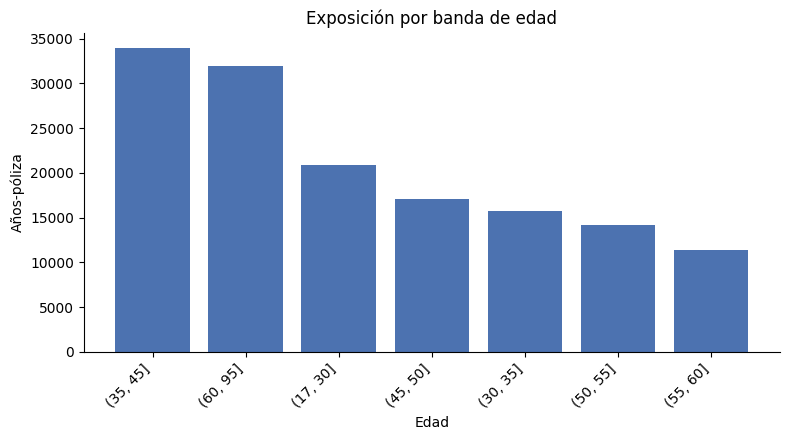

In [15]:
datos['edad_cat'] = pd.cut(datos['edad_conductor'], bins=[17,30,35,45,50,55,60,95])
tab = kpis_por(datos, 'edad_cat')
fig, ax = plt.subplots()
ax.bar(tab['edad_cat'].astype(str), tab['exposicion'], color='#4C72B0')
ax.set_title('Exposición por banda de edad'); ax.set_xlabel('Edad'); ax.set_ylabel('Años-póliza')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 8 · Del notebook al dashboard

Las funciones `kpi_frecuencia`, `kpi_severidad_media`, `kpi_prima_pura`, `kpis_por` —ya
definidas **y validadas**— son las mismas que `app_streamlit.py` va a mostrar. La app no
recalcula lógica nueva: importa/reusa estas funciones y les pone filtros y widgets.

> El notebook define y **valida**; la app presenta. Si un número está mal, se corrige aquí,
> en un solo lugar — y el cruce contra M4 y la identidad lo detectan.

El ejercicio de la sesión está en `ejercicio.py` (esqueleto con `# TODO`).